# NexaTel Customer Churn Project
## Phase 2: Exploratory Data Analysis (EDA)
**Prepared by:** Archana Arya

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
##Checking my all  CSV files are stored in the folder

import os
print("current folder:")
print(os.getcwd())

print("\nFiles and Folders here:")
print(os.listdir())

current folder:
C:\Users\Dell\Nexatel_project

Files and Folders here:
['.ipynb_checkpoints', 'billing.csv', 'cities.csv', 'complaints.csv', 'contracts.csv', 'customers.csv', 'customer_feedback.csv', 'data_quality_issue_log.csv', 'devices.csv', 'employees.csv', 'marketing_campaigns.csv', 'network_quality.csv', 'payments.csv', 'Phase1_DataCleaning_Arhana_Arya.ipynb', 'Phase2_Charts', 'Phase2_EDA_Archana_Arya.ipynb', 'plans.csv', 'plan_history.csv', 'recharges.csv', 'regions.csv', 'retention_campaigns.csv', 'states.csv', 'stores.csv', 'subscriptions.csv', 'support_tickets.csv', 'usage_data.csv', 'usage_sms.csv', 'usage_voice.csv']


In [3]:
## find and counting all csv files

csv_files = []

for files in os.listdir():
    if files.endswith(".csv"):
        csv_files.append(files)

print("Number of csv files:",len(csv_files))
print(csv_files)

Number of csv files: 24
['billing.csv', 'cities.csv', 'complaints.csv', 'contracts.csv', 'customers.csv', 'customer_feedback.csv', 'data_quality_issue_log.csv', 'devices.csv', 'employees.csv', 'marketing_campaigns.csv', 'network_quality.csv', 'payments.csv', 'plans.csv', 'plan_history.csv', 'recharges.csv', 'regions.csv', 'retention_campaigns.csv', 'states.csv', 'stores.csv', 'subscriptions.csv', 'support_tickets.csv', 'usage_data.csv', 'usage_sms.csv', 'usage_voice.csv']


In [4]:
#Loading all csv file into all_dfs

all_dfs = {}

for file in csv_files:
    table_name = file.replace(".csv","")
    all_dfs[table_name] = pd.read_csv(file,low_memory= False)

print("Number of table loaded:",len(all_dfs))
print("Table_name:",list(all_dfs.keys()))

Number of table loaded: 24
Table_name: ['billing', 'cities', 'complaints', 'contracts', 'customers', 'customer_feedback', 'data_quality_issue_log', 'devices', 'employees', 'marketing_campaigns', 'network_quality', 'payments', 'plans', 'plan_history', 'recharges', 'regions', 'retention_campaigns', 'states', 'stores', 'subscriptions', 'support_tickets', 'usage_data', 'usage_sms', 'usage_voice']


In [5]:
# select and inspect customer table

customers = all_dfs["customers"].copy()

print("Table size:",customers.shape)
print("\nColumn names:")
print(customers.columns.tolist())

print("\ncustomer_status_value:")
print(customers["customer_status"].value_counts(dropna=False))

Table size: (19076, 25)

Column names:
['customer_id', 'first_name', 'last_name', 'gender', 'date_of_birth', 'age', 'email', 'phone_number', 'address', 'city_id', 'city_name', 'state_id', 'pin_code', 'city_tier', 'region_id', 'occupation', 'annual_income_inr', 'customer_segment', 'product_line', 'plan_id', 'acquisition_channel', 'acquisition_date', 'tenure_months', 'customer_status', 'churn_date']

customer_status_value:
customer_status
Active     15560
Churned     3516
Name: count, dtype: int64


In [6]:
#Before calculating the churn rate, we must check whether duplicate customer_id values would cause customers to be counted twice.



duplicate_customer_ids = customers["customer_id"].duplicated().sum()
unique_customer_ids = customers["customer_id"].nunique()

print("Total rows:", len(customers))
print("Unique customer IDs:", unique_customer_ids)
print("Duplicate customer IDs:", duplicate_customer_ids)

Total rows: 19076
Unique customer IDs: 19000
Duplicate customer IDs: 76


In [7]:
# view all duplicate customer 



duplicate_records = customers[customers["customer_id"].duplicated(keep=False)
].sort_values("customer_id")

print("Rows involved in duplicate groups:", len(duplicate_records))

display(
    duplicate_records[
        ["customer_id", "customer_status", "churn_date"]
    ].head(10)
)


Rows involved in duplicate groups: 152


,customer_id,customer_status,churn_date
97,C0000098,Active,NaN
19044,C0000098,Active,NaN
19074,C0000169,Active,NaN
168,C0000169,Active,NaN
19025,C0000784,Active,NaN
783,C0000784,Active,NaN
1391,C0001392,Active,NaN
19051,C0001392,Active,NaN
1393,C0001394,Active,NaN
19020,C0001394,Active,NaN


In [8]:
#confirming wheather duplicate records conflicts

fully_duplicate_rows = customers.duplicated().sum()

status_count_per_id = duplicate_records.groupby(
    "customer_id")["customer_status"].nunique()

conflicting_status_ids = (status_count_per_id > 1).sum()

print("Fully identical duplicate rows:", fully_duplicate_rows)
print("Duplicate IDs with conflicting statuses:", conflicting_status_ids)

Fully identical duplicate rows: 76
Duplicate IDs with conflicting statuses: 0


In [9]:
# creating a clean customer table by removing all duplicates


clean_customer_table = customers.drop_duplicates().reset_index(drop=True)

print("Rows before cleaning:",len(customers))
print("Rows after cleaning:",len(clean_customer_table))
print("Rows Removed:",len(customers)-len(clean_customer_table))
print("Unique_customer_id:",clean_customer_table["customer_id"].nunique())



Rows before cleaning: 19076
Rows after cleaning: 19000
Rows Removed: 76
Unique_customer_id: 19000


In [10]:
#Calculate the overall churn rate


total_customers = len(clean_customer_table)

churned_customers = (clean_customer_table["customer_status"] == "Churned").sum()
active_customers = (clean_customer_table["customer_status"] == "Active").sum()
churn_rate = (churned_customers/total_customers)*100
print("total_customers:",total_customers)
print("active_customers:",active_customers)
print("churned_customers:",churned_customers)
print(f"overall churn_rate: {churn_rate:.2f}%")

total_customers: 19000
active_customers: 15494
churned_customers: 3506
overall churn_rate: 18.45%


In [11]:
chart_folder = "Phase2_Charts"

os.makedirs(chart_folder, exist_ok=True)

print("Chart folder created:", chart_folder)

Chart folder created: Phase2_Charts


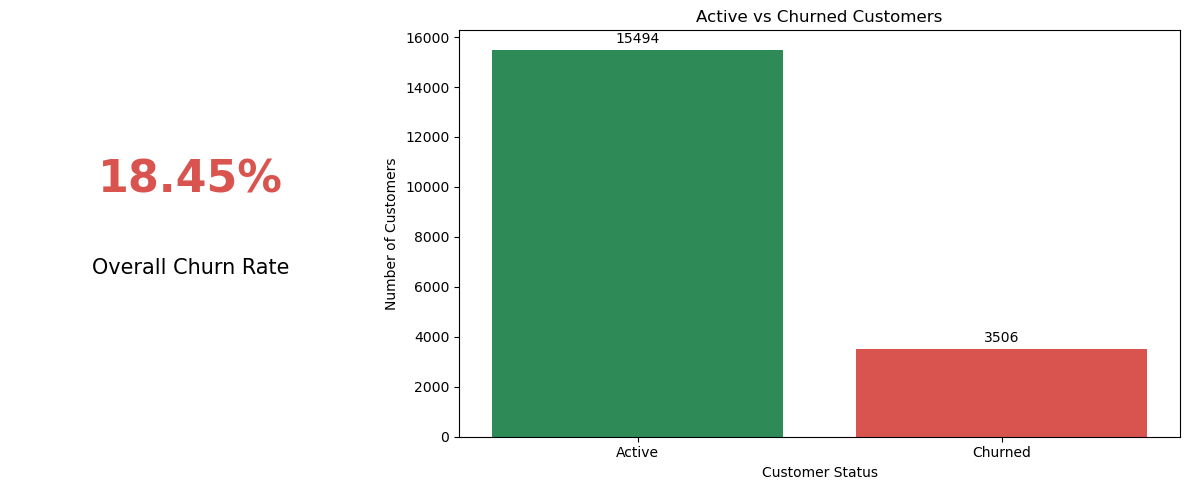

In [12]:
#Overall churn rate

status_counts = clean_customer_table["customer_status"].value_counts()
status_counts = status_counts.reindex(["Active", "Churned"])

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5),
    gridspec_kw={"width_ratios": [1, 2]})

axes[0].axis("off")
axes[0].text(
    0.5, 0.60, f"{churn_rate:.2f}%",
    ha="center", fontsize=32, fontweight="bold", color="#D9534F")
axes[0].text(
    0.5, 0.40, "Overall Churn Rate",
    ha="center", fontsize=15)

bars = axes[1].bar(
    status_counts.index,
    status_counts.values,
    color=["#2E8B57", "#D9534F"])

axes[1].set_title("Active vs Churned Customers")
axes[1].set_xlabel("Customer Status")
axes[1].set_ylabel("Number of Customers")
axes[1].bar_label(bars, padding=3)

plt.tight_layout()

plt.savefig(
    os.path.join(chart_folder, "01_overall_churn_rate.png"),
    dpi=300,
    bbox_inches="tight")

plt.show()

### Observation — Overall Churn Rate

Out of 19,000 unique customers, 3,506 have churned while 15,494 remain active. The overall churn rate is 18.45%, meaning approximately 18 out of every 100 customers have left NexaTel. Although active customers form the majority, the churned group is large enough to require further investigation into its main drivers.

In [13]:
##Chart 2: Churn by Billing Cycle. This compares customers on Monthly and Annual billing cycles.

##First, we need to inspect the subscriptions table before joining it with customer churn status.

subscriptions = all_dfs["subscriptions"].copy()

print("Table size:", subscriptions.shape)

print("\nColumn names:")
print(subscriptions.columns.tolist())

print("\nBilling cycle values:")
print(subscriptions["billing_cycle"].value_counts(dropna=False))

print("\nSubscription status values:")
print(subscriptions["subscription_status"].value_counts(dropna=False))

Table size: (20523, 8)

Column names:
['subscription_id', 'customer_id', 'plan_id', 'start_date', 'end_date', 'billing_cycle', 'monthly_charge_inr', 'subscription_status']

Billing cycle values:
billing_cycle
Monthly    15107
Annual      5416
Name: count, dtype: int64

Subscription status values:
subscription_status
Active           16930
Terminated        3491
UNKNOWN_STATE      102
Name: count, dtype: int64


In [14]:
#Checking repeated customers in subscriptions


duplicate_subscription_ids = (
    subscriptions["subscription_id"].duplicated().sum())

subscription_count_per_customer = (
    subscriptions["customer_id"].value_counts())

customers_with_multiple_subscriptions = (
    subscription_count_per_customer > 1).sum()

extra_subscription_rows = (
    subscriptions["customer_id"].duplicated().sum())

print("Duplicate subscription IDs:", duplicate_subscription_ids)
print("Unique customers in subscriptions:", subscriptions["customer_id"].nunique())
print(
    "Customers with multiple subscriptions:",
    customers_with_multiple_subscriptions)
print("Extra subscription rows:", extra_subscription_rows)

Duplicate subscription IDs: 0
Unique customers in subscriptions: 19000
Customers with multiple subscriptions: 1523
Extra subscription rows: 1523


In [15]:
#Remove invalid subscription statuses


valid_subscription_statuses = ["Active", "Terminated"]

subscriptions_clean = subscriptions[
    subscriptions["subscription_status"].isin(
        valid_subscription_statuses)].copy()

print("Rows before status cleaning:", len(subscriptions))
print("Rows after status cleaning:", len(subscriptions_clean))
print("Invalid rows removed:",
    len(subscriptions) - len(subscriptions_clean))

print("\nRemaining subscription statuses:")
print(subscriptions_clean["subscription_status"].value_counts())

Rows before status cleaning: 20523
Rows after status cleaning: 20421
Invalid rows removed: 102

Remaining subscription statuses:
subscription_status
Active        16930
Terminated     3491
Name: count, dtype: int64


In [16]:
#we need to convert start_date from text into a real date so Python can identify each customer’s latest subscription.

#Convert subscription start dates

subscriptions_clean["start_date"] = pd.to_datetime(
    subscriptions_clean["start_date"],
    format="%d-%m-%Y",
    errors="coerce")

invalid_start_dates = subscriptions_clean["start_date"].isna().sum()

print("Invalid or missing start dates:", invalid_start_dates)
print("Earliest start date:", subscriptions_clean["start_date"].min())
print("Latest start date:", subscriptions_clean["start_date"].max())

Invalid or missing start dates: 0
Earliest start date: 2014-01-01 00:00:00
Latest start date: 2027-03-11 00:00:00


In [17]:
#the latest date is 11 March 2027, which is in the future. We should count these future-dated subscriptions before selecting the latest record

#Check future subscription start dates

today = pd.Timestamp.today().normalize()

future_start_mask = (
    subscriptions_clean["start_date"] > today)

future_start_count = future_start_mask.sum()

print("Today's date:", today)
print("Future subscription start dates:", future_start_count)

Today's date: 2026-09-04 00:00:00
Future subscription start dates: 20


In [18]:
#Excluded future subscription records

subscriptions_valid_date = subscriptions_clean[
    ~future_start_mask].copy()

print("Rows before date filtering:",
    len(subscriptions_clean))
print("Rows after date filtering:",
    len(subscriptions_valid_date))
print("Future rows removed:",
    len(subscriptions_clean) - len(subscriptions_valid_date))
print("Customers remaining:",
    subscriptions_valid_date["customer_id"].nunique())

Rows before date filtering: 20421
Rows after date filtering: 20401
Future rows removed: 20
Customers remaining: 18916


In [19]:
#Create billing-cycle-specific subscription data

subscriptions_for_cycle = subscriptions.copy()

subscriptions_for_cycle["start_date"] = pd.to_datetime(
    subscriptions_for_cycle["start_date"],
    format="%d-%m-%Y",
    errors="coerce")

subscriptions_for_cycle = subscriptions_for_cycle[
    subscriptions_for_cycle["start_date"] <= today].copy()

print(
    "Subscription rows available:",
    len(subscriptions_for_cycle))
print(
    "Unique customers available:",
    subscriptions_for_cycle["customer_id"].nunique())
print(
    "Invalid billing cycles:",
    ~subscriptions_for_cycle["billing_cycle"].isin(
        ["Monthly", "Annual"])
    .sum())

Subscription rows available: 20503
Unique customers available: 19000
Invalid billing cycles: -20504


In [20]:
#Count invalid billing cycles

valid_billing_cycle_mask = subscriptions_for_cycle[
    "billing_cycle"].isin(["Monthly", "Annual"])

invalid_billing_cycles = (
    ~valid_billing_cycle_mask).sum()

print("Invalid billing cycles:", invalid_billing_cycles)

Invalid billing cycles: 0


In [21]:
#Keep each customer’s latest subscription

latest_subscriptions = (
    subscriptions_for_cycle
    .sort_values(
        ["customer_id", "start_date", "subscription_id"])
    .drop_duplicates(
        subset="customer_id",
        keep="last")
    .reset_index(drop=True))

print("Latest subscription rows:", len(latest_subscriptions))
print(
    "Unique customer IDs:",
    latest_subscriptions["customer_id"].nunique())

print("\nLatest billing-cycle counts:")
print(
    latest_subscriptions["billing_cycle"].value_counts())

Latest subscription rows: 19000
Unique customer IDs: 19000

Latest billing-cycle counts:
billing_cycle
Monthly    13998
Annual      5002
Name: count, dtype: int64


In [22]:
#Merge billing cycle with customer churn status

billing_cycle_data = pd.merge(
    clean_customer_table[
        ["customer_id", "customer_status"]
    ],
    latest_subscriptions[
        ["customer_id", "billing_cycle"]
    ],
    on="customer_id",
    how="inner",
    validate="one_to_one")

print("Merged rows:", len(billing_cycle_data))

print(
    "Unique customers:",
    billing_cycle_data["customer_id"].nunique())

print("\nMissing values:")
print(
    billing_cycle_data[
        ["customer_status", "billing_cycle"]
    ].isna().sum())

Merged rows: 19000
Unique customers: 19000

Missing values:
customer_status    0
billing_cycle      0
dtype: int64


In [23]:
#Calculate churn rate by billing cycle


billing_cycle_data["is_churned"] = (
    billing_cycle_data["customer_status"] == "Churned").astype(int)

churn_by_billing_cycle = (
    billing_cycle_data
    .groupby("billing_cycle")["is_churned"]
    .agg(["count", "sum", "mean"])
    .reset_index())

churn_by_billing_cycle = churn_by_billing_cycle.rename(
    columns={
        "count": "total_customers",
        "sum": "churned_customers",
        "mean": "churn_rate"})

churn_by_billing_cycle["churn_rate"] = (
    churn_by_billing_cycle["churn_rate"] * 100).round(2)

display(churn_by_billing_cycle)

,billing_cycle,total_customers,churned_customers,churn_rate
0,Annual,5002,391,7.82
1,Monthly,13998,3115,22.25


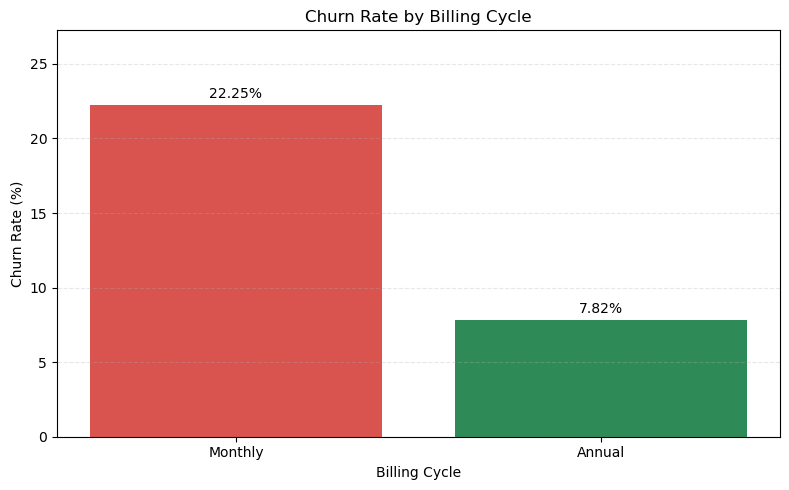

In [24]:
#Chart 2 — Churn by billing cycle


billing_chart_data = (
    churn_by_billing_cycle
    .set_index("billing_cycle")
    .loc[["Monthly", "Annual"]]
    .reset_index()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    billing_chart_data["billing_cycle"],
    billing_chart_data["churn_rate"],
    color=["#D9534F", "#2E8B57"])

plt.title("Churn Rate by Billing Cycle")
plt.xlabel("Billing Cycle")
plt.ylabel("Churn Rate (%)")

plt.bar_label(
    bars,
    labels=[
        f"{rate:.2f}%"
        for rate in billing_chart_data["churn_rate"]],padding=3)

plt.ylim(0,billing_chart_data["churn_rate"].max() + 5)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_folder,
        "02_churn_by_billing_cycle.png"),dpi=300,bbox_inches="tight")

plt.show()

### Observation — Churn by Billing Cycle

Monthly customers have a churn rate of 22.25%, compared with only 7.82% for Annual customers. This is a difference of 14.43 percentage points, and Monthly customers are approximately 2.8 times more likely to churn. NexaTel should investigate targeted retention offers or Annual-plan incentives for customers currently using Monthly billing.

In [25]:
#Chart 3: Churn by Tenure Band using tenure_months from the cleaned customers table.

#First, we must inspect the tenure values before creating the required bands.

#Inspect customer tenure

print(
    "Tenure data type:",
    clean_customer_table["tenure_months"].dtype)

print(
    "Missing tenure values:",
    clean_customer_table["tenure_months"].isna().sum())

print(
    "Minimum tenure:",
    clean_customer_table["tenure_months"].min())

print(
    "Maximum tenure:",
    clean_customer_table["tenure_months"].max())

print("\nTenure summary:")
print(
    clean_customer_table["tenure_months"].describe())

Tenure data type: int64
Missing tenure values: 0
Minimum tenure: 0
Maximum tenure: 146

Tenure summary:
count    19000.000000
mean        76.931684
std         48.174135
min          0.000000
25%         34.000000
50%         76.000000
75%        122.000000
max        146.000000
Name: tenure_months, dtype: float64


In [26]:
#Create the four tenure bands


tenure_data = clean_customer_table[
    ["customer_id", "customer_status", "tenure_months"]
].copy()

tenure_bins = [-1, 3, 12, 36, np.inf]

tenure_labels = [
    "0-3 months",
    "3-12 months",
    "1-3 years",
    "3+ years"
]

tenure_data["tenure_band"] = pd.cut(
    tenure_data["tenure_months"],
    bins=tenure_bins,
    labels=tenure_labels
)

print("Customers in each tenure band:")

print(
    tenure_data["tenure_band"].value_counts(
        sort=False
    )
)

print(
    "\nCustomers without a tenure band:",
    tenure_data["tenure_band"].isna().sum()
)

Customers in each tenure band:
tenure_band
0-3 months       749
3-12 months     1446
1-3 years       2836
3+ years       13969
Name: count, dtype: int64

Customers without a tenure band: 0


In [27]:
#Calculate churn rate by tenure band


tenure_data["is_churned"] = (
    tenure_data["customer_status"] == "Churned"
).astype(int)

churn_by_tenure = (
    tenure_data
    .groupby(
        "tenure_band",
        observed=False
    )["is_churned"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_tenure = churn_by_tenure.rename(
    columns={
        "count": "total_customers",
        "sum": "churned_customers",
        "mean": "churn_rate"
    }
)

churn_by_tenure["churn_rate"] = (
    churn_by_tenure["churn_rate"] * 100
).round(2)

display(churn_by_tenure)

,tenure_band,total_customers,churned_customers,churn_rate
0,0-3 months,749,561,74.90
1,3-12 months,1446,756,52.28
2,1-3 years,2836,1026,36.18
3,3+ years,13969,1163,8.33


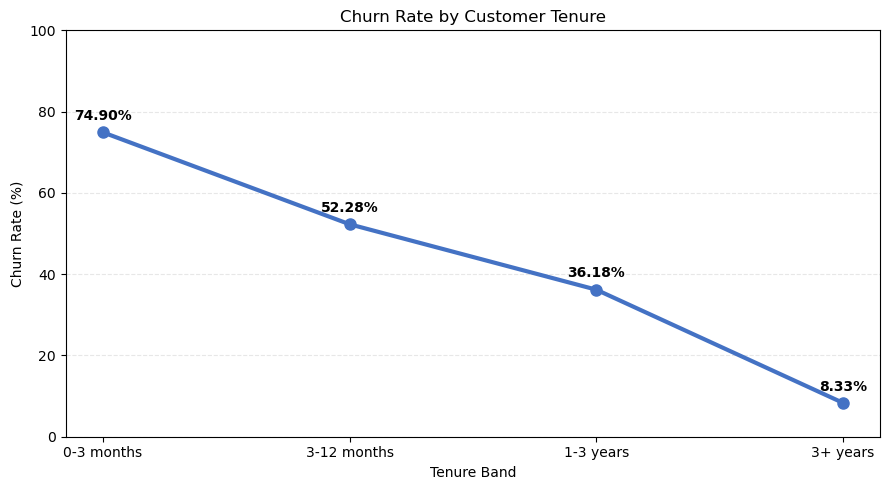

In [28]:
#Chart 3 — Churn by tenure band

x_positions = range(len(churn_by_tenure))

plt.figure(figsize=(9, 5))

plt.plot(
    x_positions,
    churn_by_tenure["churn_rate"],
    marker="o",
    markersize=8,
    linewidth=3,
    color="#4472C4"
)

plt.xticks(
    x_positions,
    churn_by_tenure["tenure_band"]
)

for x, rate in zip(
    x_positions,
    churn_by_tenure["churn_rate"]
):
    plt.text(
        x,
        rate + 3,
        f"{rate:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Band")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_folder,
        "03_churn_by_tenure_band.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation — Churn by Tenure Band

Churn is highest among customers with 0–3 months of tenure at 74.90%, followed by 52.28% among customers with 3–12 months of tenure. The rate steadily declines to 36.18% for customers with 1–3 years of tenure and only 8.33% for customers with more than 3 years. This indicates that the first year is the highest-risk period, so NexaTel should strengthen customer onboarding and early-stage retention support.

In [29]:
##Chart-4 churn by number of unresolved complaints

## inspecting the complaints data

complaints = all_dfs["complaints"].copy()
print("Table_size:",complaints.shape)
print("\ncolumn names:")
print(complaints.columns.tolist())
print("\ncomplaint status values:")
print(complaints["status"].value_counts(dropna=False))

print("\nduplicate complaint ids:",complaints["complaint_id"].duplicated().sum())

print("unique customers with complaints:",complaints["customer_id"].nunique())

Table_size: (16584, 7)

column names:
['complaint_id', 'customer_id', 'complaint_date', 'complaint_type', 'severity', 'status', 'resolution_date']

complaint status values:
status
Resolved      9236
Unresolved    7348
Name: count, dtype: int64

duplicate complaint ids: 0
unique customers with complaints: 10922


In [30]:
# now will count unresolved complaints for each customers 

unresolved_complaints = complaints[
complaints["status"]=="Unresolved"].copy()
unresolved_count_per_customer = (unresolved_complaints.groupby("customer_id").size().reset_index(name="unresolved_complaints"))
print("Total unresolved complaints:",len(unresolved_complaints))
print("customer with unresolved complaints:",unresolved_count_per_customer[
      "customer_id"].nunique())

print("maximum unresolved complaints for one customer:",unresolved_count_per_customer[
      "unresolved_complaints"].max())
print("\ndistribution among affected customers:")
print(unresolved_count_per_customer["unresolved_complaints"].value_counts().sort_index())


Total unresolved complaints: 7348
customer with unresolved complaints: 6058
maximum unresolved complaints for one customer: 5

distribution among affected customers:
unresolved_complaints
1    4934
2     975
3     133
4      15
5       1
Name: count, dtype: int64


In [31]:
#Adding the customers who have zero unresolved complaints.

#Merge complaint counts with all customers

complaint_churn_data = pd.merge(
    clean_customer_table[
        ["customer_id", "customer_status"]],
    unresolved_count_per_customer,
    on="customer_id",
    how="left",
    validate="one_to_one")

complaint_churn_data[
    "unresolved_complaints"] = complaint_churn_data[
    "unresolved_complaints"].fillna(0).astype(int)

print(
    "Total customers:",
    len(complaint_churn_data))

print("\nCustomers by unresolved-complaint count:")

print(
    complaint_churn_data[
        "unresolved_complaints"
    ].value_counts().sort_index())

print(
    "\nMissing complaint counts:",
    complaint_churn_data["unresolved_complaints"].isna().sum())

Total customers: 19000

Customers by unresolved-complaint count:
unresolved_complaints
0    12942
1     4934
2      975
3      133
4       15
5        1
Name: count, dtype: int64

Missing complaint counts: 0


##
All 19,000 customers are now included, including 12,942 customers with zero unresolved complaints.

In [32]:
##Calculate churn rate by unresolved-complaint count

complaint_churn_data["is_churned"] = (
    complaint_churn_data["customer_status"] == "Churned").astype(int)

churn_by_unresolved = (
    complaint_churn_data
    .groupby("unresolved_complaints")["is_churned"]
    .agg(["count", "sum", "mean"])
    .reset_index())

churn_by_unresolved = churn_by_unresolved.rename(
    columns={
        "count": "total_customers",
        "sum": "churned_customers",
        "mean": "churn_rate"})

churn_by_unresolved["churn_rate"] = (
    churn_by_unresolved["churn_rate"] * 100).round(2)

display(churn_by_unresolved)

,unresolved_complaints,total_customers,churned_customers,churn_rate
0,0,12942,1956,15.11
1,1,4934,1153,23.37
2,2,975,325,33.33
3,3,133,66,49.62
4,4,15,6,40.00
5,5,1,0,0.00


In [33]:
##The churn rate rises clearly from 15.11% at zero complaints to 49.62% at three complaints. However, the 4- and 5-complaint groups contain only 15 and 1 customers, so their rates are too unstable to interpret separately.

#We’ll combine them into a 3+ complaints group.

complaint_bins = [-1, 0, 1, 2, np.inf]

complaint_labels = ["0","1","2","3+"]

complaint_churn_data[
    "complaint_group"
] = pd.cut(
    complaint_churn_data[
        "unresolved_complaints"],
    bins=complaint_bins,
    labels=complaint_labels)

print("Customers in each complaint group:")

print(
    complaint_churn_data[
        "complaint_group"
    ].value_counts(sort=False))

print(
    "\nCustomers without a group:",
    complaint_churn_data[
        "complaint_group"
    ].isna().sum())




Customers in each complaint group:
complaint_group
0     12942
1      4934
2       975
3+      149
Name: count, dtype: int64

Customers without a group: 0


In [34]:
#Calculate churn rate for the grouped complaints

churn_by_complaint_group = (
    complaint_churn_data
    .groupby(
        "complaint_group",
        observed=False)["is_churned"]
    .agg(["count", "sum", "mean"])
    .reset_index())

churn_by_complaint_group = (
    churn_by_complaint_group.rename(
        columns={
            "count": "total_customers",
            "sum": "churned_customers",
            "mean": "churn_rate"}))

churn_by_complaint_group[
    "churn_rate"] = (
    churn_by_complaint_group["churn_rate"]* 100).round(2)

display(churn_by_complaint_group)

,complaint_group,total_customers,churned_customers,churn_rate
0,0,12942,1956,15.11
1,1,4934,1153,23.37
2,2,975,325,33.33
3,3+,149,72,48.32


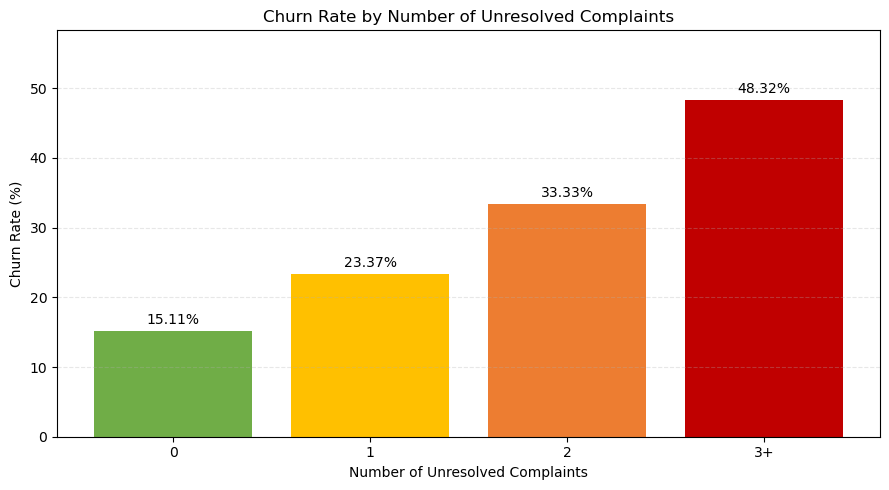

In [35]:
##Chart 4 — Churn by unresolved complaints


plt.figure(figsize=(9, 5))

bars = plt.bar(
    churn_by_complaint_group[
        "complaint_group"].astype(str),churn_by_complaint_group[
        "churn_rate"],color=[
        "#70AD47",
        "#FFC000",
        "#ED7D31",
        "#C00000"])

plt.title(
    "Churn Rate by Number of Unresolved Complaints")
plt.xlabel("Number of Unresolved Complaints")
plt.ylabel("Churn Rate (%)")

plt.bar_label(bars,labels=[f"{rate:.2f}%"
        for rate in churn_by_complaint_group["churn_rate"]],padding=3)

plt.ylim(0,churn_by_complaint_group["churn_rate"].max() + 10)

plt.grid(axis="y",linestyle="--",alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_folder,
        "04_churn_by_unresolved_complaints.png"),dpi=300,bbox_inches="tight")

plt.show()

### Observation — Churn by Unresolved Complaints

Customers with no unresolved complaints have a churn rate of 15.11%, which increases to 23.37% with one unresolved complaint and 33.33% with two. Customers with three or more unresolved complaints have the highest churn rate at 48.32%, showing a strong relationship between unresolved service problems and customer loss. NexaTel should prioritize faster complaint resolution and escalation for customers with repeated unresolved issues.

In [36]:
##•	Churn by customer segment — Mass / Value / Premium / Enterprise

all_dfs["customers"].keys()

Index(['customer_id', 'first_name', 'last_name', 'gender', 'date_of_birth',
       'age', 'email', 'phone_number', 'address', 'city_id', 'city_name',
       'state_id', 'pin_code', 'city_tier', 'region_id', 'occupation',
       'annual_income_inr', 'customer_segment', 'product_line', 'plan_id',
       'acquisition_channel', 'acquisition_date', 'tenure_months',
       'customer_status', 'churn_date'],
      dtype='object')

In [37]:
# inspecting customer segment

print("Customer segment values:")

print(
    clean_customer_table[
        "customer_segment"
    ].value_counts(dropna=False))

valid_segments = [
    "Mass",
    "Value",
    "Premium",
    "Enterprise"]

invalid_segment_count = (
    ~clean_customer_table[
        "customer_segment"
    ].isin(valid_segments)).sum()

print(
    "\nInvalid or missing segments:",
    invalid_segment_count)

Customer segment values:
customer_segment
Premium       8482
Value         6196
Mass          2932
Enterprise    1390
Name: count, dtype: int64

Invalid or missing segments: 0


In [38]:
#All 19,000 customers have a valid segment, so no cleaning is required.
#Calculating churn rate by customer segment

segment_data = clean_customer_table[
    [
        "customer_id",
        "customer_segment",
        "customer_status"
    ]
].copy()

segment_data["customer_segment"] = pd.Categorical(
    segment_data["customer_segment"],
    categories=valid_segments,
    ordered=True)

segment_data["is_churned"] = (
    segment_data["customer_status"] == "Churned").astype(int)

churn_by_segment = (
    segment_data
    .groupby(
        "customer_segment",
        observed=False)["is_churned"]
    .agg(["count", "sum", "mean"])
    .reset_index())

churn_by_segment = churn_by_segment.rename(
    columns={
        "count": "total_customers",
        "sum": "churned_customers",
        "mean": "churn_rate"})

churn_by_segment["churn_rate"] = (
    churn_by_segment["churn_rate"] * 100).round(2)

display(churn_by_segment)

,customer_segment,total_customers,churned_customers,churn_rate
0,Mass,2932,782,26.67
1,Value,6196,1275,20.58
2,Premium,8482,1283,15.13
3,Enterprise,1390,166,11.94


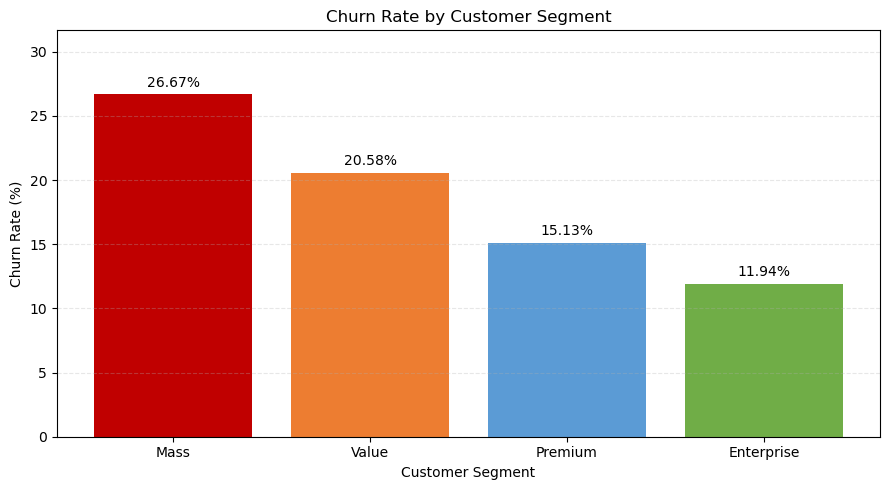

In [39]:
#Chart 5 — Churn by customer segment

plt.figure(figsize=(9, 5))

bars = plt.bar(
    churn_by_segment[
        "customer_segment"
    ].astype(str),
    churn_by_segment[
        "churn_rate"
    ],
    color=[
        "#C00000",
        "#ED7D31",
        "#5B9BD5",
        "#70AD47"
    ]
)

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")

plt.bar_label(
    bars,
    labels=[
        f"{rate:.2f}%"
        for rate in churn_by_segment[
            "churn_rate"]],padding=3)

plt.ylim(0,churn_by_segment[
        "churn_rate"].max() + 5)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_folder,
        "05_churn_by_customer_segment.png"),dpi=300,bbox_inches="tight")

plt.show()

### Observation — Churn by Customer Segment

The Mass segment has the highest churn rate at 26.67%, followed by the Value segment at 20.58%. Churn is lower among Premium customers at 15.13% and lowest among Enterprise customers at 11.94%, indicating stronger retention in higher-value segments. NexaTel should focus high-volume retention efforts on Mass and Value customers while continuing to protect its Premium and Enterprise customer relationships.

In [40]:
##•	Top 10 states/circles by churned customers — a horizontal bar chart.

#inspecting the states table

all_dfs["states"].keys()

Index(['state_id', 'state_name', 'state_code', 'zone'], dtype='object')

In [41]:
states = all_dfs["states"].copy()

print("state table size:",states.shape)

print("\ncolumn names:")
print(states.columns.tolist())

print("\nfive rows:")
display(states.head())

print("\nduplicat state ids:",states["state_id"].duplicated().sum())

print("\nmissing state ids in customers:",clean_customer_table["state_id"].isna().sum())

state table size: (36, 4)

column names:
['state_id', 'state_name', 'state_code', 'zone']

five rows:


,state_id,state_name,state_code,zone
0,ST001,Delhi,DL,North
1,ST002,Haryana,HR,North
2,ST003,Punjab,PB,North
3,ST004,Uttar Pradesh,UP,North
4,ST005,Rajasthan,RJ,North



duplicat state ids: 0

missing state ids in customers: 0


##The states table is clean:

36 states/union territories
No duplicate state_id values
No missing customer state IDs

In [42]:
#Add state names to the customer data

state_churn_data = pd.merge(clean_customer_table[["customer_id",
                                                  "state_id",
                                                  "customer_status"]],
                            states[["state_id",
                                    "state_name",
                                    "zone"]],
                            on="state_id",
                            how="left",
                            validate="many_to_one")

print("rows after merging:",len(state_churn_data))

print("unique customers:",state_churn_data["customer_id"].nunique())

print("missing state names:",state_churn_data["state_name"].isna().sum())

display(state_churn_data.head())

rows after merging: 19000
unique customers: 19000
missing state names: 0


,customer_id,state_id,customer_status,state_name,zone
0,C0000001,ST027,Churned,Chhattisgarh,East
1,C0000002,ST002,Active,Haryana,North
2,C0000003,ST011,Churned,Gujarat,West
3,C0000004,ST010,Active,Maharashtra,West
4,C0000005,ST019,Churned,Telangana,South


In [43]:
#Find the top 10 states by churned customers

churned_state_data = state_churn_data[state_churn_data["customer_status"]=="Churned"].copy()

top_10_states = (churned_state_data.groupby("state_name").size().reset_index(name="churned_customers").
                 sort_values("churned_customers",ascending=False).head(10))

display(top_10_states)

print("total churned customers in top 10 states:",top_10_states["churned_customers"].sum())


,state_name,churned_customers
15,Maharashtra,305
26,Uttar Pradesh,285
23,Tamil Nadu,280
21,Rajasthan,244
12,Karnataka,222
7,Gujarat,191
14,Madhya Pradesh,182
13,Kerala,162
0,Andhra Pradesh,160
28,West Bengal,157


total churned customers in top 10 states: 2188


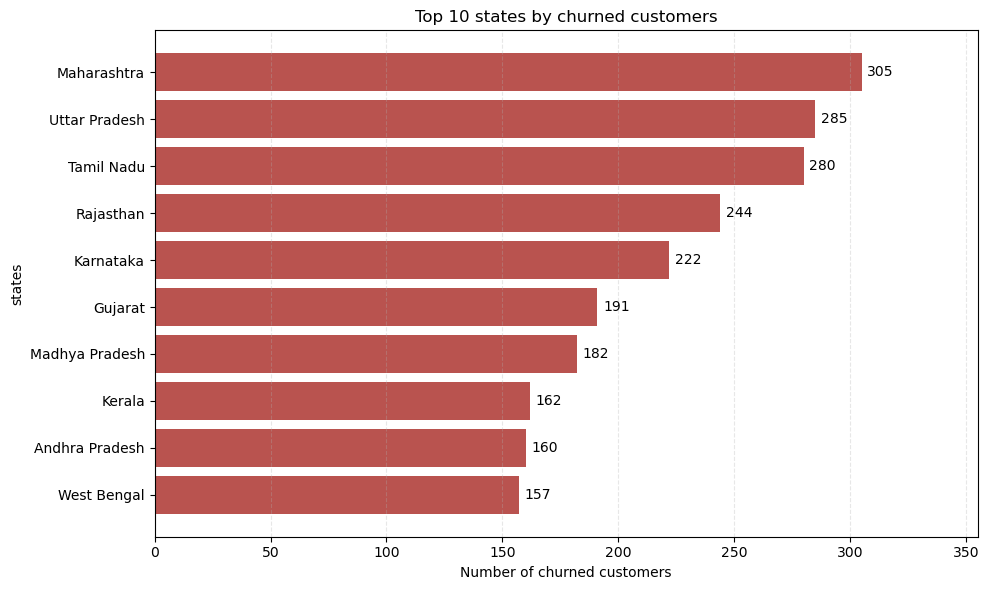

In [44]:
#The top 10 states account for 2,188 of the 3,506 churned customers. Maharashtra has the highest count at 305.

#Chart 6 — Top 10 states by churned customers

top_10_states_plot = top_10_states.sort_values("churned_customers",ascending=True)

plt.figure(figsize=(10,6))
bars = plt.barh(
    top_10_states_plot["state_name"],
    top_10_states_plot["churned_customers"],
    color = "#B9534F")

plt.title("Top 10 states by churned customers")
plt.xlabel("Number of churned customers")
plt.ylabel("states")

plt.bar_label(bars,padding=4)
plt.xlim(0,top_10_states_plot["churned_customers"].max()+50)
plt.grid(axis = "x",
         linestyle = "--",
         alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(chart_folder,"06_top_10_states_by_churned_customers.png"),
    dpi=300,
    bbox_inches="tight")

plt.show()

### Observation — Top 10 States by Churned Customers

Maharashtra has the highest number of churned customers at 305, followed by Uttar Pradesh at 285 and Tamil Nadu at 280. Together, the top 10 states account for 2,188 customers, or approximately 62.4% of all churned customers. Because this chart shows absolute counts, these states may also have larger customer bases, so state-level churn rates should be reviewed before making final regional decisions.

In [45]:
##•	Average data usage by city tier — Metro vs Tier-2 vs Tier-3 (histogram or bar).

# inspecting usage data table first

all_dfs["usage_data"].keys()



Index(['usage_id', 'customer_id', 'usage_month', 'data_gb_used',
       'data_sessions'],
      dtype='object')

In [46]:
usage_data = all_dfs["usage_data"].copy()
print("usage data size:",usage_data.shape)

print("\ncolumn names:")
print(usage_data.columns.tolist())

print("\nduplicate usage ids:",usage_data["usage_id"].duplicated().sum())

print("missing data usage value:",usage_data["data_gb_used"].isna().sum())

print("minimum data used:",usage_data["data_gb_used"].min())

print("maximum data used:",usage_data["data_gb_used"].max())




usage data size: (57000, 5)

column names:
['usage_id', 'customer_id', 'usage_month', 'data_gb_used', 'data_sessions']

duplicate usage ids: 0
missing data usage value: 0
minimum data used: 0.24
maximum data used: 22172.70070848548


In [47]:
##The table has 57,000 rows, no missing usage values, and no duplicate usage IDs. However, the maximum usage is 22,172.70 GB, which is extremely high and would distort the average.

##Before calculating city-tier averages, we’ll identify high-usage outliers using the IQR method.





In [48]:
#Calculate the outlier limit

q1 = usage_data["data_gb_used"].quantile(0.25)
q3 = usage_data["data_gb_used"].quantile(0.75)

iqr = q3-q1

upper_limit = q3 + (1.5*iqr)

high_usage_outliers = usage_data[usage_data["data_gb_used"]>upper_limit]

print("Q1:",round(q1,2))
print("Q3:",round(q3,2))
print("IQR:",round(iqr,2))
print("upper outlier limit:",round(upper_limit,2))

print("Number of high usage outliers:",len(high_usage_outliers))

print("Outliers percentage:",round(len(high_usage_outliers)/len(usage_data)*100,2),"%")

Q1: 11.39
Q3: 32.63
IQR: 21.24
upper outlier limit: 64.49
Number of high usage outliers: 4480
Outliers percentage: 7.86 %


In [49]:
##The IQR rule flagged 4,480 rows (7.86%), but we should not automatically remove all of them. Telecom data usage is naturally right-skewed: some customers genuinely use much more data than others.

##The value 22,172 GB looks suspicious, but values slightly above 64.49 GB may still be legitimate. Let’s inspect the upper end before cleaning.

In [50]:
##Inspect the highest usage values

usage_percentiles = usage_data["data_gb_used"].quantile([0.90,
                                                         0.95,
                                                         0.99,
                                                         0.995,
                                                         0.999])
print("upper usage percentiles:")
print(usage_percentiles,round(2))

print("\nTen higest usage records:")

display(usage_data[["customer_id","usage_month","data_gb_used"]].sort_values("data_gb_used",ascending=False
                                                                            ).head(10)
       )

upper usage percentiles:
0.900      56.390000
0.950      79.080000
0.990     140.670900
0.995     179.021250
0.999    4331.530484
Name: data_gb_used, dtype: float64 2

Ten higest usage records:


,customer_id,usage_month,data_gb_used
15077,C0005026,01-2026,22172.700708
23089,C0007697,02-2026,21960.635745
10054,C0003352,02-2026,18348.446462
34859,C0011620,01-2026,17377.228312
26592,C0008865,03-2026,15322.701632
29837,C0009946,01-2026,13886.727541
53991,C0017998,03-2026,13344.522727
56096,C0018699,01-2026,13154.906387
45208,C0015070,02-2026,12747.455634
19929,C0006644,03-2026,12581.380386


#The percentile results show an important gap:

99% of records are at or below 140.67 GB
99.5% are at or below 179.02 GB
The 99.9th percentile suddenly jumps to 4,331.53 GB

This suggests a small group of extreme values measured in thousands of GB, while normal high usage is generally below 200 GB. We should test a conservative 1,000 GB threshold before cleaning.

In [51]:
#Count clearly extreme usage records


extreme_usage_limit = 1000

extreme_usage_records = usage_data[
    usage_data["data_gb_used"] > extreme_usage_limit].copy()

largest_value_below_limit = usage_data.loc[
    usage_data["data_gb_used"] <= extreme_usage_limit,
    "data_gb_used"].max()

smallest_value_above_limit = extreme_usage_records[
    "data_gb_used"].min()

print(
    "Records above 1,000 GB:",
    len(extreme_usage_records))

print(
    "Percentage above 1,000 GB:",
    round(
        len(extreme_usage_records)
        / len(usage_data) * 100,2),"%")

print(
    "Largest value at or below the limit:",
    round(largest_value_below_limit, 2))

print(
    "Smallest value above the limit:",
    round(smallest_value_above_limit, 2))

Records above 1,000 GB: 149
Percentage above 1,000 GB: 0.26 %
Largest value at or below the limit: 985.04
Smallest value above the limit: 1040.76


In [52]:
#Flag usage outliers

phase1_usage_limit = 350

usage_data["usage_outlier_flag"] = (
    usage_data["data_gb_used"] > phase1_usage_limit)

print(
    "Flagged usage outliers:",
    usage_data["usage_outlier_flag"].sum())

print(
    "Outlier percentage:",
    round(
        usage_data["usage_outlier_flag"].mean() * 100,2),"%")

print(
    "Unflagged usage records:",
    (~usage_data["usage_outlier_flag"]).sum())

Flagged usage outliers: 171
Outlier percentage: 0.3 %
Unflagged usage records: 56829


In [53]:
#Merge data usage with customer city tier

city_usage_data = pd.merge(
    usage_data,
    clean_customer_table[
        ["customer_id", "city_tier"]],
    on="customer_id",
    how="left",
    validate="many_to_one")

print("Rows after merging:",len(city_usage_data))

print("Unique customers:",
    city_usage_data["customer_id"].nunique())

print("Missing city tiers:",
    city_usage_data["city_tier"].isna().sum())

print("\nUsage records by city tier:")

print(city_usage_data[
        "city_tier"].value_counts(dropna=False))

Rows after merging: 57000
Unique customers: 19000
Missing city tiers: 0

Usage records by city tier:
city_tier
Tier-2    27633
Tier-3    14790
Metro     14577
Name: count, dtype: int64


In [54]:
#Comparing raw and outlier-adjusted averages

raw_average_by_tier = (
    city_usage_data
    .groupby("city_tier")["data_gb_used"]
    .mean())

unflagged_usage_data = city_usage_data[
    ~city_usage_data["usage_outlier_flag"]].copy()

adjusted_average_by_tier = (
    unflagged_usage_data
    .groupby("city_tier")["data_gb_used"]
    .mean())

usage_average_comparison = pd.DataFrame({
    "raw_average_gb": raw_average_by_tier,
    "adjusted_average_gb": adjusted_average_by_tier})

usage_average_comparison = (
    usage_average_comparison
    .reindex(["Metro", "Tier-2", "Tier-3"])
    .round(2)
    .reset_index())

display(usage_average_comparison)

,city_tier,raw_average_gb,adjusted_average_gb
0,Metro,49.19,36.01
1,Tier-2,41.75,26.53
2,Tier-3,28.38,18.38


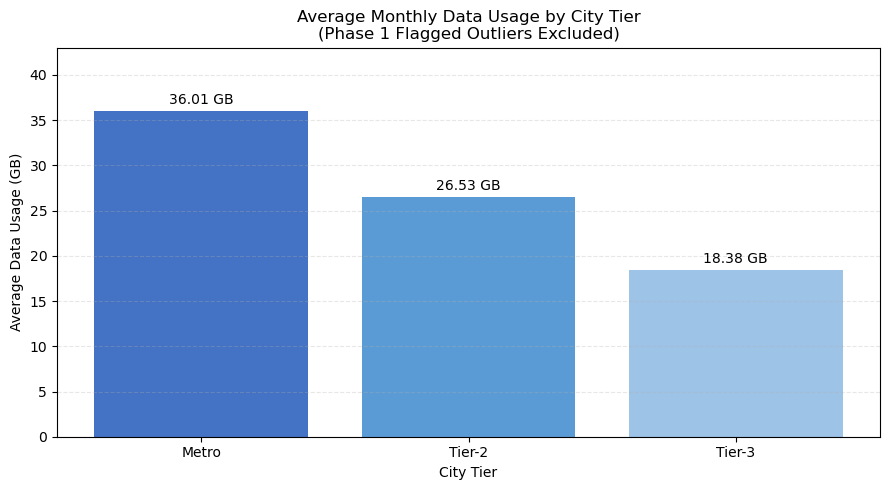

In [55]:
#Chart 7 — Average data usage by city tier

plt.figure(figsize=(9, 5))

bars = plt.bar(
    usage_average_comparison["city_tier"],
    usage_average_comparison["adjusted_average_gb"],
    color=[
        "#4472C4",
        "#5B9BD5",
        "#9DC3E6"
    ]
)

plt.title(
    "Average Monthly Data Usage by City Tier\n"
    "(Phase 1 Flagged Outliers Excluded)"
)

plt.xlabel("City Tier")
plt.ylabel("Average Data Usage (GB)")

plt.bar_label(bars,labels=[f"{value:.2f} GB"
        for value in usage_average_comparison["adjusted_average_gb"]],padding=3)

plt.ylim(0,usage_average_comparison[
        "adjusted_average_gb"].max() + 7)

plt.grid(axis="y",linestyle="--",alpha=0.3)

plt.tight_layout()

plt.savefig(os.path.join(chart_folder,
        "07_average_data_usage_by_city_tier.png"),dpi=300,bbox_inches="tight")

plt.show()

### Observation — Average Data Usage by City Tier

After excluding the 171 usage records flagged during Phase 1, Metro customers have the highest average monthly data usage at 36.01 GB. Average usage decreases to 26.53 GB in Tier-2 cities and 18.38 GB in Tier-3 cities, meaning Metro usage is almost twice the Tier-3 average. This pattern suggests greater digital-service usage or demand among Metro customers, which NexaTel can consider when planning network capacity and targeted data plans.

In [56]:
#•	ARPU distribution — a histogram of monthly charge across the base.

#inspecting monthly charge

print(
    "Monthly charge data type:",
    latest_subscriptions[
        "monthly_charge_inr"].dtype)

print(
    "Missing monthly charges:",
    latest_subscriptions[
        "monthly_charge_inr"].isna().sum())

print("Negative monthly charges:",
    (latest_subscriptions["monthly_charge_inr"] < 0).sum())

print("Minimum monthly charge:",
    latest_subscriptions["monthly_charge_inr"].min())

print("Maximum monthly charge:",
    latest_subscriptions["monthly_charge_inr"].max())

print("\nMonthly charge summary:")

print(latest_subscriptions[
        "monthly_charge_inr"].describe())

Monthly charge data type: float64
Missing monthly charges: 0
Negative monthly charges: 0
Minimum monthly charge: 99.0
Maximum monthly charge: 8333.0

Monthly charge summary:
count    19000.000000
mean       845.080000
std       1321.721437
min         99.000000
25%        300.000000
50%        499.000000
75%        899.000000
max       8333.000000
Name: monthly_charge_inr, dtype: float64


#The monthly-charge data is clean: no missing or negative values. The mean is ₹845.08, while the median is ₹499, indicating a right-skewed distribution caused by higher-priced customer plans.


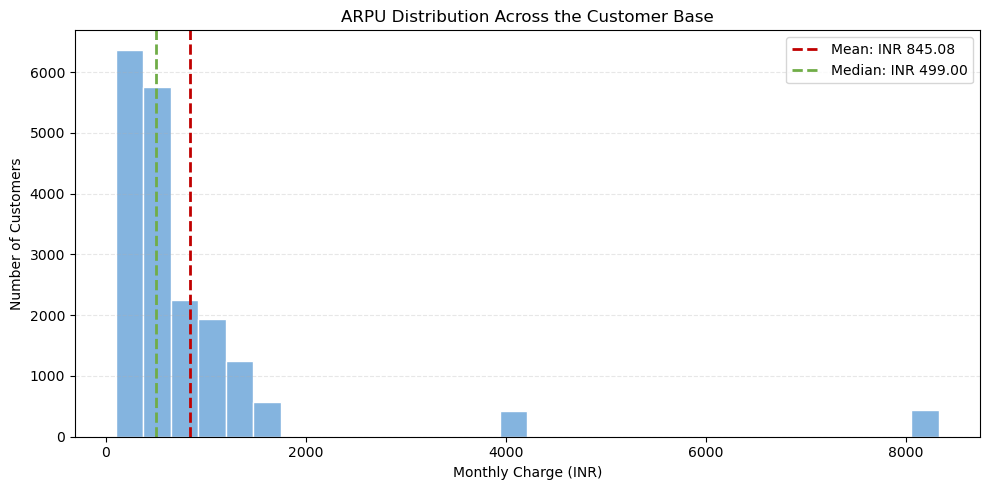

In [57]:
#Chart 8 — ARPU distribution

monthly_charges = latest_subscriptions[
    "monthly_charge_inr"
]

mean_monthly_charge = monthly_charges.mean()
median_monthly_charge = monthly_charges.median()

plt.figure(figsize=(10, 5))

sns.histplot(
    monthly_charges,
    bins=30,
    color="#5B9BD5",
    edgecolor="white"
)

plt.axvline(
    mean_monthly_charge,
    color="#C00000",
    linestyle="--",
    linewidth=2,
    label=f"Mean: INR {mean_monthly_charge:,.2f}")

plt.axvline(
    median_monthly_charge,
    color="#70AD47",
    linestyle="--",
    linewidth=2,
    label=f"Median: INR {median_monthly_charge:,.2f}")

plt.title("ARPU Distribution Across the Customer Base")
plt.xlabel("Monthly Charge (INR)")
plt.ylabel("Number of Customers")
plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_folder,
        "08_arpu_distribution.png"),
    dpi=300,
    bbox_inches="tight")

plt.show()

### Observation — ARPU Distribution

Most customers are concentrated in the lower monthly-charge ranges, while relatively small customer groups have charges near INR 4,000 and INR 8,333. The mean monthly charge is INR 845.08, which is considerably higher than the median of INR 499, confirming that the distribution is right-skewed. The higher-priced plans increase overall ARPU even though most customers pay less than the average.

In [58]:
#•	Network quality vs churn — scatter or grouped bar of dropped-call rate vs churn.


#Inspect the network-quality table

network_quality = all_dfs["network_quality"].copy()

print("Network-quality table size:",network_quality.shape)

print("\nColumn names:")

print(network_quality.columns.tolist())

print("\nUnique customers:",network_quality["customer_id"].nunique())

print("\nFirst five rows:")

display(network_quality.head())

Network-quality table size: (57000, 8)

Column names:
['record_id', 'customer_id', 'city_id', 'month', 'avg_signal_strength_dbm', 'dropped_call_rate_pct', 'avg_download_speed_mbps', 'network_downtime_hours']

Unique customers: 19000

First five rows:


,record_id,customer_id,city_id,month,avg_signal_strength_dbm,dropped_call_rate_pct,avg_download_speed_mbps,network_downtime_hours
0,NQ00000001,C0000001,CT0026,03-2026,-74.3,3.15,25.1,0.87
1,NQ00000002,C0000001,CT0026,02-2026,-74.3,3.39,64.9,0.13
2,NQ00000003,C0000001,CT0026,01-2026,-74.3,1.75,68.7,0.46
3,NQ00000004,C0000002,CT0009,03-2026,-69.9,2.92,73.1,0.17
4,NQ00000005,C0000002,CT0009,02-2026,-69.9,3.02,75.3,0.33


In [59]:
#Validate dropped-call-rate data

print("Duplicate network record IDs:",
    network_quality["record_id"].duplicated().sum())

print("Missing dropped-call rates:",
    network_quality["dropped_call_rate_pct"].isna().sum())

print("Dropped-call-rate data type:",
    network_quality["dropped_call_rate_pct"].dtype)

print("Minimum dropped-call rate:",
    network_quality["dropped_call_rate_pct"].min())

print("Maximum dropped-call rate:",
    network_quality["dropped_call_rate_pct"].max())

print("\nDropped-call-rate summary:")

print(network_quality["dropped_call_rate_pct"].describe())

Duplicate network record IDs: 0
Missing dropped-call rates: 0
Dropped-call-rate data type: float64
Minimum dropped-call rate: 0.04
Maximum dropped-call rate: 9.82

Dropped-call-rate summary:
count    57000.000000
mean         2.401331
std          1.291287
min          0.040000
25%          1.460000
50%          2.230000
75%          3.180000
max          9.820000
Name: dropped_call_rate_pct, dtype: float64


The dropped-call-rate data is valid:

No missing values
No duplicate record IDs
Range: 0.04% to 9.82%
Overall mean: 2.40%

Because each customer has three monthly records, we should first calculate one average dropped-call rate per customer. Otherwise, each customer would be counted three times.

In [60]:
#Calculate average dropped-call rate per customer

customer_network_average = (
    network_quality.groupby("customer_id").agg(
        average_dropped_call_rate=("dropped_call_rate_pct",
            "mean"),months_observed=("record_id","count")).reset_index())

customer_network_average["average_dropped_call_rate"
] = customer_network_average["average_dropped_call_rate"].round(2)

print("Customers in network summary:",
    len(customer_network_average))

print("Minimum months per customer:",
    customer_network_average[
        "months_observed"].min())

print("Maximum months per customer:",
    customer_network_average[
        "months_observed"].max())

display(customer_network_average.head())

Customers in network summary: 19000
Minimum months per customer: 3
Maximum months per customer: 3


,customer_id,average_dropped_call_rate,months_observed
0,C0000001,2.76,3
1,C0000002,3.13,3
2,C0000003,1.43,3
3,C0000004,1.20,3
4,C0000005,2.43,3


In [61]:
#Merge network quality with churn status


network_churn_data = pd.merge(
    customer_network_average,
    clean_customer_table[
        ["customer_id", "customer_status"]],
    on="customer_id",
    how="inner",
    validate="one_to_one")

print("Rows after merging:",
    len(network_churn_data))

print("Unique customers:",
    network_churn_data[
        "customer_id"].nunique())

print("Missing churn statuses:",
    network_churn_data[
        "customer_status"].isna().sum())

print(
    "Missing network averages:",
    network_churn_data[
        "average_dropped_call_rate"].isna().sum())

display(network_churn_data.head())

Rows after merging: 19000
Unique customers: 19000
Missing churn statuses: 0
Missing network averages: 0


,customer_id,average_dropped_call_rate,months_observed,customer_status
0,C0000001,2.76,3,Churned
1,C0000002,3.13,3,Active
2,C0000003,1.43,3,Churned
3,C0000004,1.20,3,Active
4,C0000005,2.43,3,Churned


In [62]:
#Compare network quality by churn status

network_status_summary = (network_churn_data.groupby("customer_status")
    .agg(total_customers=("customer_id","count"),
        mean_dropped_call_rate=("average_dropped_call_rate","mean"),
        median_dropped_call_rate=("average_dropped_call_rate","median"))
    .reindex(["Active", "Churned"]).round(2).reset_index())

display(network_status_summary)

,customer_status,total_customers,mean_dropped_call_rate,median_dropped_call_rate
0,Active,15494,2.36,2.29
1,Churned,3506,2.59,2.54


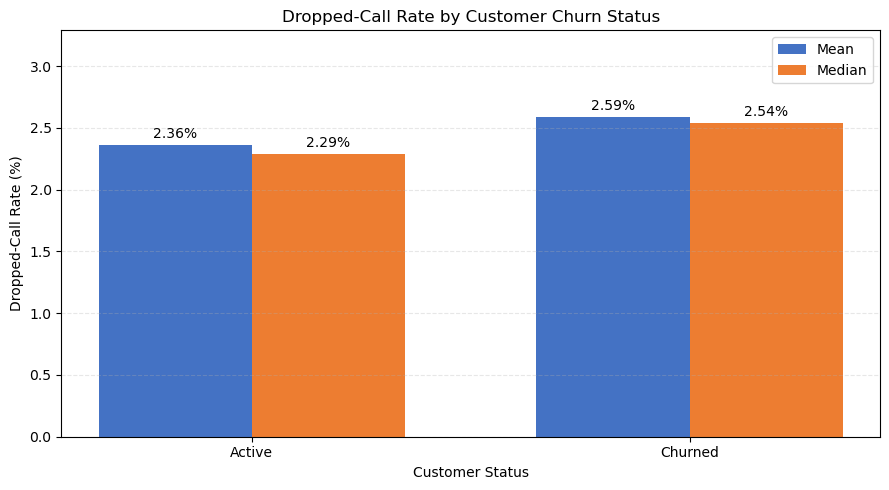

In [63]:
#Chart 9 — Network quality vs churn


x_positions = np.arange(
    len(network_status_summary))

bar_width = 0.35

fig, ax = plt.subplots(
    figsize=(9, 5))

mean_bars = ax.bar(
    x_positions - bar_width / 2,
    network_status_summary["mean_dropped_call_rate"],
    width=bar_width,label="Mean",color="#4472C4")

median_bars = ax.bar(x_positions + bar_width / 2,
    network_status_summary["median_dropped_call_rate"],
    width=bar_width,
    label="Median",
    color="#ED7D31")

ax.set_title("Dropped-Call Rate by Customer Churn Status")
ax.set_xlabel("Customer Status")
ax.set_ylabel("Dropped-Call Rate (%)")

ax.set_xticks(x_positions)

ax.set_xticklabels(network_status_summary["customer_status"])

ax.bar_label(mean_bars,labels=[f"{value:.2f}%"
        for value in network_status_summary["mean_dropped_call_rate"]],
    padding=3)

ax.bar_label(median_bars,labels=[f"{value:.2f}%"
        for value in network_status_summary[
            "median_dropped_call_rate"]],padding=3)

ax.set_ylim(0,network_status_summary[
        "mean_dropped_call_rate"].max() + 0.7)

ax.legend()

ax.grid(axis="y",linestyle="--",alpha=0.3)

plt.tight_layout()

plt.savefig(os.path.join(
        chart_folder,"09_network_quality_vs_churn.png"),
    dpi=300,bbox_inches="tight")

plt.show()

### Observation — Network Quality vs Churn

Churned customers experienced a mean dropped-call rate of 2.59%, compared with 2.36% for Active customers—a difference of 0.23 percentage points. The median results show the same pattern at 2.54% for Churned customers and 2.29% for Active customers, indicating that the difference is consistent across the groups. This suggests an association between poorer call quality and churn, although it does not prove that dropped calls alone caused customers to leave.

In [64]:
#•	Retention campaign outcomes — accepted / declined / no response, and retained share.


#Inspect the retention campaign data


retention_campaigns = all_dfs["retention_campaigns"].copy()

print("Retention campaign table size:", retention_campaigns.shape)

print("\nColumn names:")
print(retention_campaigns.columns.tolist())

print("\nFirst five rows:")
display(retention_campaigns.head())

Retention campaign table size: (6475, 8)

Column names:
['campaign_id', 'customer_id', 'campaign_name', 'offer_type', 'contact_date', 'channel', 'response', 'retained_flag']

First five rows:


,campaign_id,customer_id,campaign_name,offer_type,contact_date,channel,response,retained_flag
0,RTC0000001,C0000004,Renewal Nudge,Annual Plan Discount,04-09-2025,SMS,Declined,Yes
1,RTC0000002,C0000009,Renewal Nudge,Cashback Voucher,08-01-2026,Call,Declined,Yes
2,RTC0000003,C0000015,Loyalty Save,Extra Data 50GB,23-02-2025,WhatsApp,Accepted,Yes
3,RTC0000004,C0000016,At-Risk Outreach,Free OTT 3 Months,08-01-2026,WhatsApp,Accepted,No
4,RTC0000005,C0000017,Loyalty Save,Plan Upgrade Offer,22-05-2025,Email,Accepted,No


In [65]:
#Validate the outcome columns

print("Duplicate campaign IDs:",retention_campaigns["campaign_id"].duplicated().sum())

print("\nCampaign response values:")
print(retention_campaigns["response"].value_counts(dropna=False))

print("\nRetained-flag values:")
print(retention_campaigns["retained_flag"].value_counts(dropna=False))

print("\nMissing values:")
print(retention_campaigns[["response", "retained_flag"]].isna().sum())

Duplicate campaign IDs: 0

Campaign response values:
response
Accepted       2982
Declined       1877
No Response    1616
Name: count, dtype: int64

Retained-flag values:
retained_flag
Yes    5337
No     1138
Name: count, dtype: int64

Missing values:
response         0
retained_flag    0
dtype: int64


In [66]:
#Check whether customers received multiple campaigns

campaigns_per_customer = (retention_campaigns.groupby("customer_id").size())

print("Unique customers contacted:",
    retention_campaigns["customer_id"].nunique())

print("Customers contacted more than once:",
    (campaigns_per_customer > 1).sum())

print("Maximum campaigns for one customer:",
    campaigns_per_customer.max())

Unique customers contacted: 6475
Customers contacted more than once: 0
Maximum campaigns for one customer: 1


In [67]:
#Calculate retention by campaign response



retention_analysis = retention_campaigns.copy()

retention_analysis["retained_binary"] = (retention_analysis["retained_flag"]
    .map({"Yes": 1, "No": 0}))

response_order = [
    "Accepted",
    "Declined",
    "No Response"]

retention_summary = (retention_analysis.groupby("response").agg(
        total_customers=("customer_id", "count"),
        retained_customers=("retained_binary", "sum"))
    .reindex(response_order)
    .reset_index())

retention_summary["retained_share"] = (retention_summary["retained_customers"]
    / retention_summary["total_customers"]* 100).round(2)

display(retention_summary)

,response,total_customers,retained_customers,retained_share
0,Accepted,2982,2589,86.82
1,Declined,1877,1486,79.17
2,No Response,1616,1262,78.09


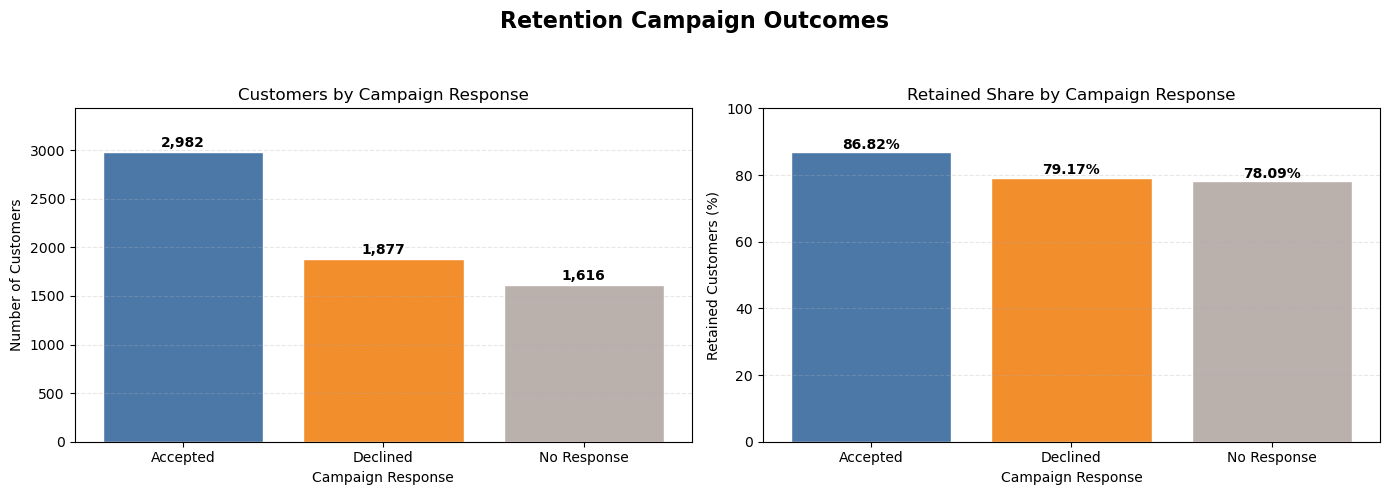

In [68]:
#Create and save Chart 10


response_colors = [
    "#4C78A8",
    "#F28E2B",
    "#BAB0AC"
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Left chart: number of customers by response
count_bars = axes[0].bar(
    retention_summary["response"],
    retention_summary["total_customers"],
    color=response_colors,
    edgecolor="white")

axes[0].set_title("Customers by Campaign Response")
axes[0].set_xlabel("Campaign Response")
axes[0].set_ylabel("Number of Customers")
axes[0].set_ylim(0,retention_summary["total_customers"].max() * 1.15)
axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.3)

for bar, value in zip(count_bars,retention_summary["total_customers"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + 50,
        f"{value:,}",
        ha="center",
        fontweight="bold")

# Right chart: retained share by response
share_bars = axes[1].bar(
    retention_summary["response"],
    retention_summary["retained_share"],
    color=response_colors,
    edgecolor="white")

axes[1].set_title("Retained Share by Campaign Response")
axes[1].set_xlabel("Campaign Response")
axes[1].set_ylabel("Retained Customers (%)")
axes[1].set_ylim(0, 100)
axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.3)

for bar, value in zip(
    share_bars,
    retention_summary["retained_share"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold")

fig.suptitle(
    "Retention Campaign Outcomes",
    fontsize=16,
    fontweight="bold")

plt.tight_layout(
    rect=[0, 0, 1, 0.93])

plt.savefig(
    f"{chart_folder}/10_retention_campaign_outcomes.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

### Observation — Retention Campaign Outcomes

Among the 6,475 customers contacted, Accepted was the largest response group with 2,982 customers and had the highest retained share at 86.82%. Retention among customers who accepted was 7.65 percentage points higher than Declined customers (79.17%) and 8.73 percentage points higher than customers who gave No Response (78.09%). This indicates that campaign acceptance is associated with stronger retention, although the observational data does not prove that accepting an offer directly caused customers to remain.

In [69]:
#Verify all saved chart files



saved_charts = sorted([
        file_name
        for file_name in os.listdir(chart_folder)
        if file_name.lower().endswith(".png")])

print("Total PNG charts saved:", len(saved_charts))

print("\nSaved chart files:")

for chart_number, file_name in enumerate(
    saved_charts,
    start=1):print(chart_number, "-", file_name)

Total PNG charts saved: 10

Saved chart files:
1 - 01_overall_churn_rate.png
2 - 02_churn_by_billing_cycle.png
3 - 03_churn_by_tenure_band.png
4 - 04_churn_by_unresolved_complaints.png
5 - 05_churn_by_customer_segment.png
6 - 06_top_10_states_by_churned_customers.png
7 - 07_average_data_usage_by_city_tier.png
8 - 08_arpu_distribution.png
9 - 09_network_quality_vs_churn.png
10 - 10_retention_campaign_outcomes.png


## Phase 2 — Key Takeaways

- NexaTel’s overall customer churn rate is **18.45%**, representing 3,506 churned customers out of 19,000 unique customers.
- Monthly-plan customers have a significantly higher churn rate (**22.25%**) than Annual-plan customers (**7.82%**), making billing-cycle conversion an important retention opportunity.
- Early-tenure customers are the highest-risk group: churn falls from **74.90%** among customers with 0–3 months of tenure to **8.33%** among customers with more than three years of tenure.
- Churn rises with unresolved complaints, increasing from **15.11%** for customers with no unresolved complaints to **48.32%** for customers with three or more.
- Mass customers have the highest segment churn rate at **26.67%**, while Enterprise customers have the lowest at **11.94%**.
- The top 10 states contribute **2,188 churned customers**, approximately **62.4%** of total churn, with Maharashtra recording the highest count at 305.
- After excluding the 171 Phase 1 flagged usage outliers, average monthly data usage is highest in Metro cities at **36.01 GB**, followed by Tier-2 at **26.53 GB** and Tier-3 at **18.38 GB**.
- Monthly charges are strongly right-skewed: the mean is **INR 845.08**, while the median is **INR 499.00**, showing that a smaller number of expensive plans increase the average.
- Churned customers have a slightly higher mean dropped-call rate (**2.59%**) than Active customers (**2.36%**), suggesting that network quality may contribute to churn risk.
- Among campaign-targeted customers, those who accepted an offer had the highest retained share at **86.82%**, compared with **79.17%** for Declined and **78.09%** for No Response.

### Analytical Notes

- These findings show associations and should not be interpreted as proof of causation.
- State-level results are based on churn counts and may be influenced by the number of customers in each state.
- Retention-campaign results apply only to the 6,475 customers included in the campaign dataset.